In [ ]:
# ===========================================
# INSTALACIONES
# ===========================================
!pip install -q kagglehub gensim
!pip install -q nltk fastai

In [ ]:
# ===========================================
# LIBRERÍAS
# ===========================================
import os
import re
import nltk
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import RegexpTokenizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from gensim.models import Word2Vec
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import kagglehub
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from fastai.text.all import *

In [ ]:
# ===========================================
# DESCARGA DEL DATASET
# ===========================================
path = kagglehub.dataset_download("yasserh/imdb-movie-ratings-sentiment-analysis")
print("Dataset descargado en:", path)

data = pd.read_csv(os.path.join(path, "movie.csv"))
print(data.head())

Using Colab cache for faster access to the 'imdb-movie-ratings-sentiment-analysis' dataset.
Dataset descargado en: /kaggle/input/imdb-movie-ratings-sentiment-analysis
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      text  \
0  I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No one wanted to be Alan. 

In [ ]:
# ===========================================
# DUPLICADOS
# ===========================================
duplicados = data[data.duplicated()]
print("Duplicados encontrados:", len(duplicados))

x_raw = data["text"]
y_raw = data["label"]

Duplicados encontrados: 277


In [ ]:
# ===========================================
# TRAIN / INFERENCE SPLIT
# ===========================================
x, x_inference, y, y_inference = train_test_split(
    x_raw, y_raw, test_size=0.01, random_state=42, stratify=data["label"]
)

nltk.download(['stopwords', 'snowball_data', 'punkt'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package snowball_data to /root/nltk_data...
[nltk_data]   Package snowball_data is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# ===========================================
# PREPROCESAMIENTO (TU CÓDIGO)
# ===========================================
def limpiar_texto(textos):
    return textos.apply(
        lambda texto: re.sub(
            r'http\S+|www\S+|https\S+|\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b|\d+',
            '',
            str(texto).lower()
        )
    )
def preprocesar_y_normalizar(textos):
    tokenizer = RegexpTokenizer(r'\w+')
    stop_words = set(stopwords.words('english'))
    stemmer = SnowballStemmer('english')
    procesados = []
    for texto in textos:
        tokens = tokenizer.tokenize(texto.lower())
        tokens = [t for t in tokens if t not in stop_words]
        tokens = [stemmer.stem(t) for t in tokens]
        procesados.append(" ".join(tokens))
    return pd.Series(procesados)

In [ ]:
# ===========================================
# PREPROCESAMIENTO PARA ULMFiT
# ===========================================
x_clean = limpiar_texto(x)
x_clean = preprocesar_y_normalizar(x_clean)

df_ulmfit = pd.DataFrame({
    "text": x_clean,
    "label": y.reset_index(drop=True)
})

In [ ]:
# ===========================================
# SPLIT PARA ULMFiT
# ===========================================
df_ulmfit_train, df_ulmfit_valid = train_test_split(
    df_ulmfit, test_size=0.2, random_state=42, stratify=df_ulmfit["label"]
)

In [ ]:
# ===========================================
# DATALOADERS ULMFiT
# ===========================================
dls = TextDataLoaders.from_df(
    df_ulmfit,
    text_col="text",
    label_col="label",
    valid_pct=0.2,
    seed=42,
    bs=64
)

In [ ]:
# ===========================================
# MODELO ULMFiT
# ===========================================
learn = text_classifier_learner(
    dls,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy
)

In [ ]:
# ===========================================
# ENTRENAMIENTO
# ===========================================
learn.fine_tune(4)

epoch,train_loss,valid_loss,accuracy,time
0,0.620190,0.582528,0.710985,01:11


epoch,train_loss,valid_loss,accuracy,time
0,0.501156,0.443557,0.799242,03:15
1,0.434981,0.406046,0.813131,03:16
2,0.404335,0.368068,0.840278,03:17
3,0.382312,0.361299,0.842677,03:17


In [ ]:
# ===========================================
# ENTRENAMIENTO SIN fine_tune()
# ===========================================
print("\n=== Etapa 1: Entrenamiento con encoder congelado ===")
learn.freeze()
learn.fit_one_cycle(2, 1e-2)

print("\n=== Etapa 2: Entrenamiento desbloqueando encoder ===")
learn.unfreeze()
learn.fit_one_cycle(5, 1e-3)


=== Etapa 1: Entrenamiento con encoder congelado ===


epoch,train_loss,valid_loss,accuracy,time
0,0.612633,0.583770,0.691288,1:14:02
1,0.593356,0.560213,0.721717,1:14:08



=== Etapa 2: Entrenamiento desbloqueando encoder ===


epoch,train_loss,valid_loss,accuracy,time


In [ ]:
# ===========================================
# EVALUACIÓN
# ===========================================
preds, targs = learn.get_preds()
pred_labels = preds.argmax(dim=1)

from sklearn.metrics import accuracy_score
accuracy_ulmfit = accuracy_score(targs, pred_labels)
print("\n🔥 Accuracy ULMFiT:", accuracy_ulmfit)


🔥 Accuracy ULMFiT: 0.8426767676767677


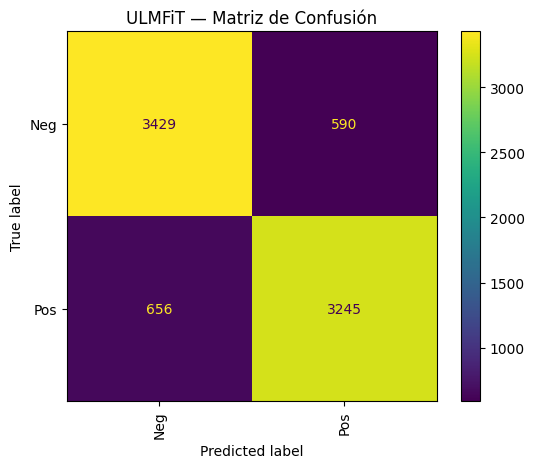

In [ ]:
# ===========================================
# MATRIZ DE CONFUSIÓN
# ===========================================
cm = confusion_matrix(targs, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=["Neg", "Pos"])
disp.plot(xticks_rotation='vertical')
plt.title("ULMFiT — Matriz de Confusión")
plt.show()

In [ ]:
# ===========================================
# GRAFICA DE LOSS
# ===========================================

rec = learn.recorder

train_losses = rec.losses
valid_losses = [v[0] for v in rec.values]

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(
    np.linspace(0, len(train_losses), len(valid_losses)),
    valid_losses,
    label='Validation Loss',
    marker='o'
)
plt.title("ULMFiT — Training vs Validation Loss")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# ===========================================
# GRAFICA DE ACCURACY
# ===========================================

val_acc = [v[1] for v in rec.values]

plt.figure(figsize=(8,5))
plt.plot(val_acc, marker='o')
plt.title("ULMFiT — Validation Accuracy por Época")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


In [ ]:
len(learn.dls.train)


495

In [ ]:
learn.cbs


(#7) [TrainEvalCallback,Recorder,CastToTensor,ProgressCallback,ModelResetter,RNNCallback,RNNRegularizer]

In [ ]:
learn.recorder.final_record


(#2) [0.3612993061542511,0.8426767587661743]

In [ ]:
learn.logger

<function print(*args, sep=' ', end='\n', file=None, flush=False)>